In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

WITH_ADDUCT_MASS_CSV = "../../testset_predictions_ohe_adductmass.csv"
WITHOUT_ADDUCT_MASS_CSV = "../../testset_predictions_ohe.csv"

with_df = pd.read_csv(WITH_ADDUCT_MASS_CSV)
without_df = pd.read_csv(WITHOUT_ADDUCT_MASS_CSV)

# Global style settings
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"], # Standard crisp fonts
    "axes.linewidth": 1.5,               # Thicker axis lines
    "axes.spines.top": False,            # Remove top spine
    "axes.spines.right": False,          # Remove right spine
    "xtick.major.width": 1.5,            # Match tick thickness to axis
    "ytick.major.width": 1.5,
    "xtick.direction": "out",            # Ticks point outside
    "ytick.direction": "out",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
})

print(f"With adduct mass: {len(with_df)} rows | Without adduct mass: {len(without_df)} rows")

With adduct mass: 12802 rows | Without adduct mass: 12802 rows


In [2]:
merged = with_df.merge(
    without_df, on=["SMILES", "Adduct", "CCS_True"], suffixes=("_with", "_without"),
)

print(f"Matched rows: {len(merged)} / {len(with_df)} (with) / {len(without_df)} (without)")

ccs_true = merged["CCS_True"]
rel_err_with = (merged["CCS_Pred_with"] - ccs_true).abs() / ccs_true * 100
rel_err_without = (merged["CCS_Pred_without"] - ccs_true).abs() / ccs_true * 100

print(f"With adduct mass    | mean RE: {rel_err_with.mean():.4f}% | median RE: {rel_err_with.median():.4f}%")
print(f"Without adduct mass | mean RE: {rel_err_without.mean():.4f}% | median RE: {rel_err_without.median():.4f}%")

Matched rows: 12802 / 12802 (with) / 12802 (without)
With adduct mass    | mean RE: 1.7333% | median RE: 1.2308%
Without adduct mass | mean RE: 1.7508% | median RE: 1.2456%


In [3]:
statistic, p_value = wilcoxon(rel_err_with, rel_err_without)

print(f"Paired Wilcoxon signed-rank test | statistic={statistic:.2f} | p={p_value:.4e}")
print(
    "Significant at alpha=0.05" if p_value < 0.05 else "Not significant at alpha=0.05",
    "-- adduct mass", "reduces" if rel_err_with.median() < rel_err_without.median() else "increases",
    "median relative error",
)

Paired Wilcoxon signed-rank test | statistic=39748978.00 | p=3.3432e-03
Significant at alpha=0.05 -- adduct mass reduces median relative error


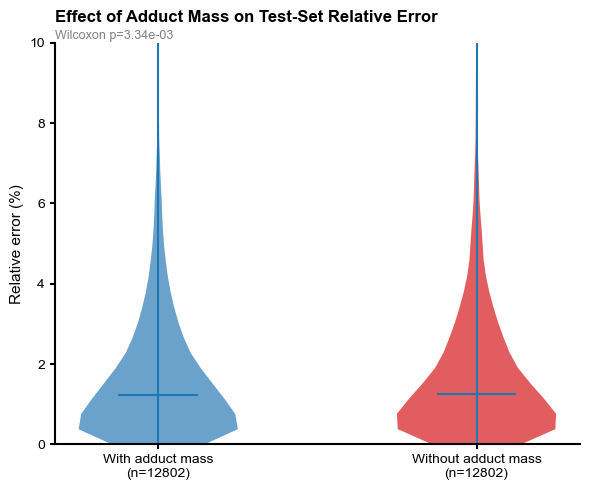

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))

parts = ax.violinplot([rel_err_with, rel_err_without], positions=[0, 1], showmedians=True)
for pc, color in zip(parts["bodies"], ["#2c7bb6", "#d7191c"]):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax.set_xticks([0, 1])
ax.set_xticklabels([f"With adduct mass\n(n={len(merged)})", f"Without adduct mass\n(n={len(merged)})"])
ax.set_ylabel("Relative error (%)")
ax.set_ylim(0, 10)  # zoomed to ~99th percentile -- a long tail (max ~38%) otherwise dwarfs the median difference
ax.set_title("Effect of Adduct Mass on Test-Set Relative Error", loc="left", fontweight="bold", pad=15)
ax.text(0, 1.01, f"Wilcoxon p={p_value:.2e}",
        transform=ax.transAxes, fontsize=9, color="gray")

plt.tight_layout()
plt.show()